<a href="https://colab.research.google.com/github/AnnieNyasha/new/blob/main/Finalcopy_all_indices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# --- Google Drive Mounting ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- Install Required Libraries ---
!pip install geopandas fiona shapely pyproj rasterio fastkml pykml

# ------------------------------- Imports -----------------------------------------
import os
import glob
import rasterio
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import zipfile
import random

from shapely.geometry import shape
from fastkml import kml
from pykml import parser as kml_parser
from matplotlib.colors import ListedColormap
from rasterio.features import geometry_mask
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import recall_score, precision_score, f1_score
from rasterio.plot import show
from matplotlib import colors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix



output_dir = '/content/drive/MyDrive/MSC-001/PLOTS'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.4/114.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.9 MB/s eta 0:00:00


NDBI



# ------------------------------- Load Data ------------------------------------
NDBI images: ['BX_NDBI_2017_05_25.tif', 'BX_NDBI_2017_12_31.tif', 'BX_NDBI_2018_06_19.tif', 'BX_NDBI_2019_03_31.tif', 'BX_NDBI_2020_01_10.tif', 'BX_NDBI_2020_01_30.tif', 'BX_NDBI_2024_05_03.tif']
Pond polygons: ['BX_2017_05_25pond.shp', 'BX_2017_12_31pond.shp', 'BX_2018_06_19pond.shp', 'BX_2019_03_31pond.shp', 'BX_2020_01_10pond.shp', 'BX_2020_01_30pond.shp', 'BX_2024_05_03pond.shp']
WT polygons: ['BX_2017_05_25wt.shp', 'BX_2017_12_31wt.shp', 'BX_2018_06_19wt.shp', 'BX_2019_03_31wt.shp', 'BX_2020_01_10wt.shp', 'BX_2020_01_30wt.shp', 'BX_2024_05_03wt.shp']

Matched dates: ['2017-05-25', '2017-12-31', '2018-06-19', '2019-03-31', '2020-01-10', '2020-01-30', '2024-05-03']

# -------------------- Pixel breakdown per date -------------------------------
2017-05-25: Pond=62 | WT=71
2017-12-31: Pond=83 | WT=81
2018-06-19: Pond=57 | WT=40
2019-03-31: Pond=125 | WT=131
2020-01-10: Pond=105 | WT=131
2020-01-30: Pond

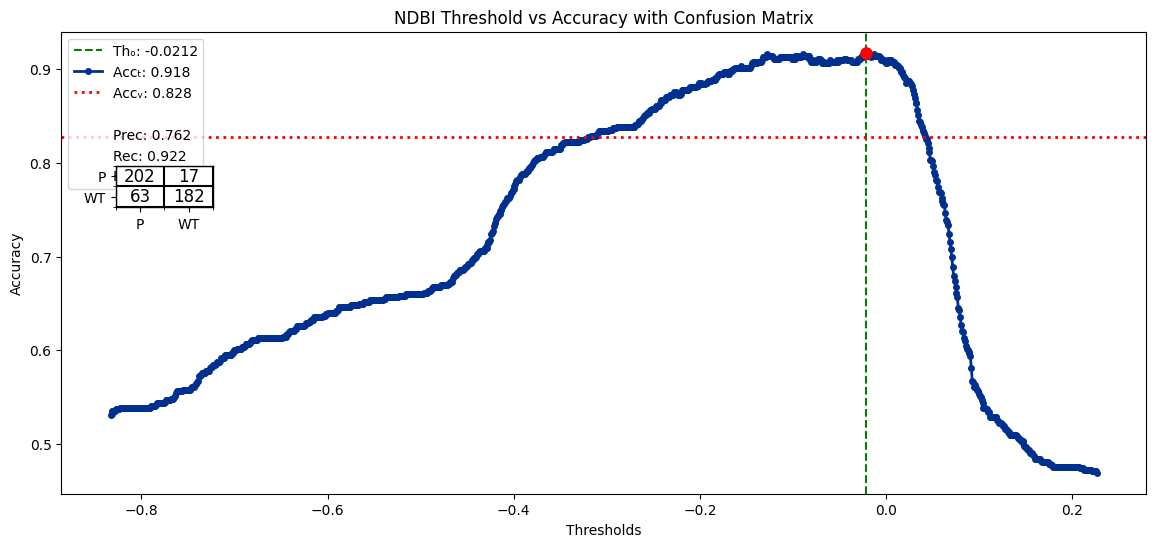


# ====================== SUMMARY STATISTICS ================================
# Site: BX
# --------------------------------------------------------------------------
Metric                                             Value
----------------------------------------------------------
Training pixels – Pond                               291
Training pixels – WT                                 329
Training pixels – Total                              620
Testing pixels – Pond                                219
Testing pixels – WT                                  245
Testing pixels – Total                               464
----------------------------------------------------------
NDBI Optimal threshold (median)                  -0.0212
NDBI Validation OA                                0.8276
# ==========================================================================



In [ ]:
SITE = "BX"
# ============================ CONFIGURATION ===================================
# ============================ NDBI NDBI NDBI NDBI ===================================

INPUT_PATH = "/content/drive/MyDrive/MSC-001/MSC/ALLINDICES"
OUTPUT_CSV = f"/content/drive/MyDrive/MSC-001/PLOTS/{SITE}/raw_NDBI_PixelClassifications_ALL.csv"
TRAINING_CSV = f"/content/drive/MyDrive/MSC-001/PLOTS/{SITE}ndbitraining_pixels.csv"

RANDOM_SEED = 8
TRAIN_RATIO = 0.6

CUSTOM_COLORS = [
    '#B820FF', '#7B53FD', '#388BFA', '#3F85FB', '#36B1F2', '#6CCCE3',
    '#B4E5D1', '#CCDDB1', '#D7C787', '#D6C98B', '#D3AC61', '#BD883B', '#8E4900'
]
CUSTOM_CMAP = ListedColormap(CUSTOM_COLORS)

# ============================ IMPORTS =========================================
import os
import re
import random
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from rasterio.features import geometry_mask
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

# ============================ HELPER FUNCTIONS ================================

def balanced_date_split(date_counts):
    all_dates = date_counts.index.tolist()
    n_train = max(1, round(TRAIN_RATIO * len(all_dates)))

    total_pond = date_counts["pond"].sum()
    total_wt = date_counts["wt"].sum()
    target_ratio = total_pond / (total_pond + total_wt)

    best_split, best_balance = None, float("inf")
    from itertools import combinations

    for train_idx in combinations(all_dates, n_train):
        train_dates = list(train_idx)
        test_dates = [d for d in all_dates if d not in train_dates]

        train = date_counts.loc[train_dates].sum()
        test = date_counts.loc[test_dates].sum()

        if train.sum() == 0 or test.sum() == 0:
            continue

        balance = abs(train["pond"] / train.sum() - target_ratio) + \
                  abs(test["pond"] / test.sum() - target_ratio)

        if balance < best_balance:
            best_balance = balance
            best_split = (train_dates, test_dates)

    return best_split


def extract_date(fname):
    m = re.search(r'(\d{4})_(\d{2})_(\d{2})', fname)
    return f"{m.group(1)}-{m.group(2)}-{m.group(3)}" if m else None


def extract_ndbi_values(ndbi_path, pond_path, wt_path):
    with rasterio.open(ndbi_path) as src:
        pond = gpd.read_file(pond_path).to_crs(src.crs)
        wt = gpd.read_file(wt_path).to_crs(src.crs)

        pond_mask = geometry_mask(pond.geometry, src.shape, src.transform, invert=True)
        wt_mask = geometry_mask(wt.geometry, src.shape, src.transform, invert=True)

        data = src.read(1)
        if src.nodata is not None:
            pond_vals = data[pond_mask & (data != src.nodata)]
            wt_vals = data[wt_mask & (data != src.nodata)]
        else:
            pond_vals = data[pond_mask]
            wt_vals = data[wt_mask]

    return pond_vals, wt_vals

# =============================== MAIN =========================================

def main():
    random.seed(RANDOM_SEED)

    print("\n# ------------------------------- Load Data ------------------------------------")

    all_files = [f for f in os.listdir(INPUT_PATH) if not f.startswith(".")]

    ndbi_files = sorted([f for f in all_files if f.upper().startswith(f"{SITE}_NDBI") and f.lower().endswith(".tif")])
    pond_files = sorted([f for f in all_files if f.upper().startswith(f"{SITE}_") and "pond" in f.lower() and f.lower().endswith(".shp")])
    wt_files   = sorted([f for f in all_files if f.upper().startswith(f"{SITE}_") and "wt"   in f.lower() and f.lower().endswith(".shp")])

    print("NDBI images:", ndbi_files)
    print("Pond polygons:", pond_files)
    print("WT polygons:", wt_files)

    date_to_ndbi = {extract_date(f): f for f in ndbi_files}
    date_to_pond = {extract_date(f): f for f in pond_files}
    date_to_wt   = {extract_date(f): f for f in wt_files}

    common_dates = sorted(set(date_to_ndbi) & set(date_to_pond) & set(date_to_wt))
    if not common_dates:
        raise ValueError("No common dates found")

    print("\nMatched dates:", common_dates)

    pixel_arrays, pixel_breakdown = {}, {}

    print("\n# -------------------- Pixel breakdown per date -------------------------------")
    for d in common_dates:
        p, w = extract_ndbi_values(
            os.path.join(INPUT_PATH, date_to_ndbi[d]),
            os.path.join(INPUT_PATH, date_to_pond[d]),
            os.path.join(INPUT_PATH, date_to_wt[d])
        )
        pixel_arrays[d] = {"pond_vals": p, "wt_vals": w}
        pixel_breakdown[d] = {"pond": len(p), "wt": len(w)}
        print(f"{d}: Pond={len(p)} | WT={len(w)}")

    df_counts = pd.DataFrame.from_dict(pixel_breakdown, orient="index")
    train_dates, test_dates = balanced_date_split(df_counts)

    print("\nTrain dates:", train_dates)
    print("Test dates:", test_dates)

    # ---------------- TRAIN / TEST PIXELS -------------------------------------
    train_df = pd.concat([
        pd.DataFrame({
            "date": d,
            "value": np.concatenate([pixel_arrays[d]["pond_vals"], pixel_arrays[d]["wt_vals"]]),
            "class_code": [1]*len(pixel_arrays[d]["pond_vals"]) + [0]*len(pixel_arrays[d]["wt_vals"])
        }) for d in train_dates
    ])

    test_df = pd.concat([
        pd.DataFrame({
            "date": d,
            "value": np.concatenate([pixel_arrays[d]["pond_vals"], pixel_arrays[d]["wt_vals"]]),
            "class_code": [1]*len(pixel_arrays[d]["pond_vals"]) + [0]*len(pixel_arrays[d]["wt_vals"])
        }) for d in test_dates
    ])

    print(f"\nTraining pixels: {len(train_df)}")
    print(f"Testing pixels: {len(test_df)}")

    # ---------------- THRESHOLD OPTIMISATION ----------------------------------
    values = train_df["value"].values
    labels = train_df["class_code"].values

    global_min, global_max = np.nanmin(values), np.nanmax(values)
    print(f"\nGlobal NDBI range: {global_min:.4f} to {global_max:.4f}")

    thresholds = np.arange(global_min, global_max + 0.001, 0.001)

    fine_results = []
    for t in thresholds:
        pred = (values < t).astype(int)
        oa_t = (pred == labels).mean()
        fine_results.append({"threshold": t, "OA": oa_t})

    fine_df = pd.DataFrame(fine_results)

    # --------- MEDIAN OF ALL THRESHOLDS REACHING MAX OA -----------
    max_oa = fine_df["OA"].max()
    optimal_thresholds = fine_df.loc[fine_df["OA"] == max_oa, "threshold"].values
    optimal_threshold = np.median(optimal_thresholds)
    training_acc_optimal = max_oa

    print("\n# ------------------ OPTIMAL THRESHOLD CANDIDATES ---------------------------")
    print(f"Maximum Training OA: {max_oa:.4f}")
    print(f"Number of thresholds achieving max OA: {len(optimal_thresholds)}")
    print(f"Threshold range yielding max OA:")
    print(f"  Min threshold: {optimal_thresholds.min():.6f}")
    print(f"  Max threshold: {optimal_thresholds.max():.6f}")
    print(f"Selected threshold (median): {optimal_threshold:.6f}")
    print(f"Training OA: {training_acc_optimal:.4f}")

    # ---------------- VALIDATION ----------------------------------------------
    test_df["pred"] = (test_df["value"] < optimal_threshold).astype(int)
    oa = (test_df["pred"] == test_df["class_code"]).mean()

    actual = test_df["class_code"].values
    pred = test_df["pred"].values

    TP = np.sum((actual == 1) & (pred == 1))
    TN = np.sum((actual == 0) & (pred == 0))
    FP = np.sum((actual == 0) & (pred == 1))
    FN = np.sum((actual == 1) & (pred == 0))

    precision = TP / (TP + FP) if TP + FP else 0
    recall    = TP / (TP + FN) if TP + FN else 0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0

    print("\n# ------------------ VALIDATION METRICS ----------------------------------------")
    print(f"Validation OA: {oa:.4f}")
    print(f"Precision:     {precision:.4f}")
    print(f"Recall:        {recall:.4f}")
    print(f"F1 score:      {f1:.4f}")
    print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

    # ===================== PLOTTING WITH DYNAMIC INSET ================================
    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(fine_df["threshold"], fine_df["OA"],
             marker="o", markersize=4, color="#00308F", linewidth=2)

    ax1.scatter([optimal_threshold], [training_acc_optimal],
                color="red", marker="o", s=65, zorder=5)

    ax1.axvline(optimal_threshold, color="green", linestyle="--", linewidth=1.5)
    ax1.axhline(oa, color="red", linestyle=":", linewidth=2)

    ax1.set_xlabel("Thresholds")
    ax1.set_ylabel("Accuracy")
    ax1.set_title("NDBI Threshold vs Accuracy with Confusion Matrix")

    cm = confusion_matrix(actual, pred, labels=[1, 0])

    # ===================== DYNAMIC INSET PLACEMENT ==============================
    x_norm = (fine_df["threshold"] - fine_df["threshold"].min()) / \
             (fine_df["threshold"].max() - fine_df["threshold"].min())
    y_norm = (fine_df["OA"] - fine_df["OA"].min()) / \
             (fine_df["OA"].max() - fine_df["OA"].min())

    quadrants = {
        "UL": ((x_norm < 0.5) & (y_norm > 0.5)).sum(),
        "UR": ((x_norm > 0.5) & (y_norm > 0.5)).sum(),
        "LL": ((x_norm < 0.5) & (y_norm < 0.5)).sum(),
        "LR": ((x_norm > 0.5) & (y_norm < 0.5)).sum(),
    }

    best_quad = min(quadrants, key=quadrants.get)

    anchors = {
        "UL": (0.05, 0.62),
        "UR": (0.62, 0.62),
        "LL": (0.05, 0.05),
        "LR": (0.62, 0.05),
    }

    bx, by = anchors[best_quad]

    ax_inset = inset_axes(
        ax1,
        width="30%",
        height="30%",
        bbox_to_anchor=(bx, by, 0.3, 0.3),
        bbox_transform=ax1.transAxes,
        loc="lower left",
        borderpad=0
    )

    ax_inset.set_xlim(-0.5, 1.5)
    ax_inset.set_ylim(1.5, -0.5)
    ax_inset.set_facecolor("white")

    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

    ax_inset.set_xticks([0, 1])
    ax_inset.set_yticks([0, 1])
    ax_inset.set_xticklabels(["P", "WT"], fontsize=10)
    ax_inset.set_yticklabels(["P", "WT"], fontsize=10)

    ax_inset.set_xticks(np.arange(-0.5, 2), minor=True)
    ax_inset.set_yticks(np.arange(-0.5, 2), minor=True)
    ax_inset.grid(which="minor", color="black", linestyle="-", linewidth=1.5)

    for i in range(2):
        for j in range(2):
            ax_inset.text(j, i, f"{cm[i, j]:,}",
                          ha="center", va="center", fontsize=12)

    handles = [
        plt.Line2D([0], [0], color="green", linestyle="--", linewidth=1.5),
        plt.Line2D([0], [0], color="#00308F", marker="o", markersize=4, linewidth=2),
        plt.Line2D([0], [0], color="red", linestyle=":", linewidth=2),
        plt.Line2D([0], [0], color="none"),
        plt.Line2D([0], [0], color="none"),
        plt.Line2D([0], [0], color="none"),
        plt.Line2D([0], [0], color="none"),
    ]

    labels = [
        f"Thₒ: {optimal_threshold:.3g}",
        f"Accₜ: {training_acc_optimal:.3g}",
        f"Accᵥ: {oa:.3g}",
        "",
        f"Prec: {precision:.3g}",
        f"Rec: {recall:.3g}",
        f"F1: {f1:.3g}",
    ]

    ax1.legend(handles, labels, loc="upper left", fontsize=10, frameon=True)

    plt.savefig(
        f"/content/drive/MyDrive/MSC-001/PLOTS/NDBI/{SITE}_threshold_CM_inset.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ===================== SUMMARY TABLE ======================================
    train_pond = (train_df["class_code"] == 1).sum()
    train_wt   = (train_df["class_code"] == 0).sum()
    train_tot  = len(train_df)

    test_pond = (test_df["class_code"] == 1).sum()
    test_wt   = (test_df["class_code"] == 0).sum()
    test_tot  = len(test_df)

    print("\n# ====================== SUMMARY STATISTICS ================================")
    print(f"# Site: {SITE}")
    print("# --------------------------------------------------------------------------")
    print(f"{'Metric':<40} {'Value':>15}")
    print("-" * 58)

    print(f"{'Training pixels – Pond':<40} {train_pond:>15,}")
    print(f"{'Training pixels – WT':<40} {train_wt:>15,}")
    print(f"{'Training pixels – Total':<40} {train_tot:>15,}")

    print(f"{'Testing pixels – Pond':<40} {test_pond:>15,}")
    print(f"{'Testing pixels – WT':<40} {test_wt:>15,}")
    print(f"{'Testing pixels – Total':<40} {test_tot:>15,}")

    print("-" * 58)
    print(f"{'NDBI Optimal threshold (median)':<40} {optimal_threshold:>15.4f}")
    print(f"{'NDBI Validation OA':<40} {oa:>15.4f}")
    print("# ==========================================================================\n")


if __name__ == "__main__":
    main()

# NDWI MNDWI NDMI NMDI SWI RATIO




# ------------------------------- Load Data ------------------------------------
MNDWI images: ['BX_MNDWI_2017_05_25.tif', 'BX_MNDWI_2017_12_31.tif', 'BX_MNDWI_2018_06_19.tif', 'BX_MNDWI_2019_03_31.tif', 'BX_MNDWI_2020_01_10.tif', 'BX_MNDWI_2020_01_30.tif', 'BX_MNDWI_2024_05_03.tif']
Pond polygons: ['BX_2017_05_25pond.shp', 'BX_2017_12_31pond.shp', 'BX_2018_06_19pond.shp', 'BX_2019_03_31pond.shp', 'BX_2020_01_10pond.shp', 'BX_2020_01_30pond.shp', 'BX_2024_05_03pond.shp']
WT polygons: ['BX_2017_05_25wt.shp', 'BX_2017_12_31wt.shp', 'BX_2018_06_19wt.shp', 'BX_2019_03_31wt.shp', 'BX_2020_01_10wt.shp', 'BX_2020_01_30wt.shp', 'BX_2024_05_03wt.shp']

Matched dates: ['2017-05-25', '2017-12-31', '2018-06-19', '2019-03-31', '2020-01-10', '2020-01-30', '2024-05-03']

# -------------------- Pixel breakdown per date -------------------------------
2017-05-25: Pond=62 | WT=71
2017-12-31: Pond=83 | WT=81
2018-06-19: Pond=57 | WT=40
2019-03-31: Pond=125 | WT=131
2020-01-10: Pond=105 | WT=131
2020-01-

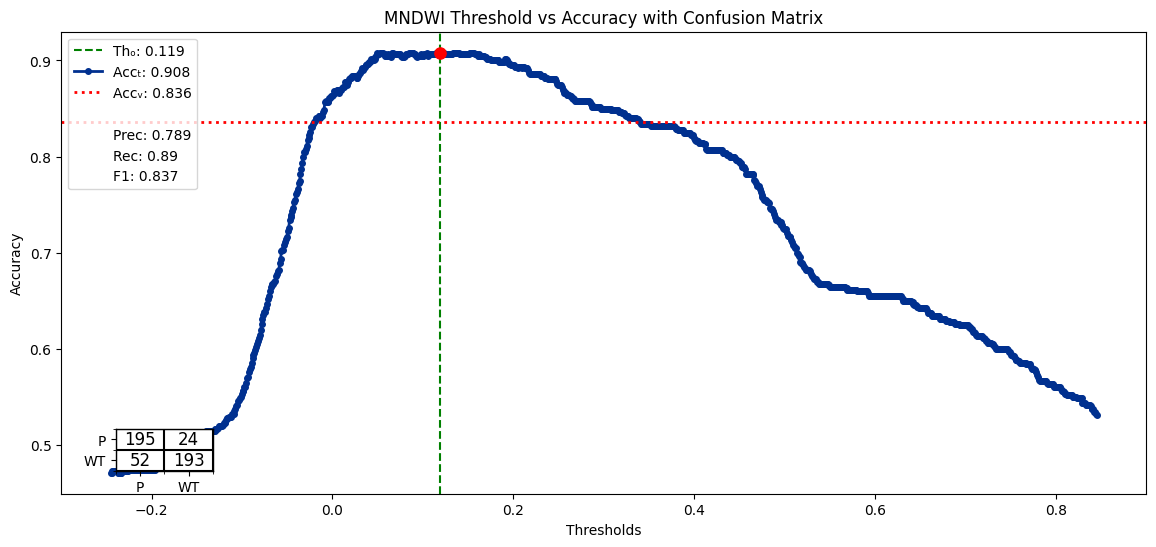


# ====================== SUMMARY STATISTICS ================================
# Site: BX
# --------------------------------------------------------------------------
Metric                                             Value
----------------------------------------------------------
Training pixels – Pond                               291
Training pixels – WT                                 329
Training pixels – Total                              620
Testing pixels – Pond                                219
Testing pixels – WT                                  245
Testing pixels – Total                               464
----------------------------------------------------------
MNDWI Optimal threshold (median)                  0.1191
MNDWI Validation OA                               0.8362
# ==========================================================================



In [4]:
# ============================ CONFIGURATION ===================================
# ============================ {INDEX} {INDEX} {INDEX} ===================================

SITE = "BX"
INDEX = "MNDWI"

INPUT_PATH = "/content/drive/MyDrive/MSC-001/MSC/ALLINDICES"
OUTPUT_CSV = f"/content/drive/MyDrive/MSC-001/PLOTS/{SITE}/raw_{INDEX}_PixelClassifications_ALL.csv"
TRAINING_CSV = f"/content/drive/MyDrive/MSC-001/PLOTS/{SITE}{INDEX.lower()}_training_pixels.csv"

RANDOM_SEED = 8
TRAIN_RATIO = 0.6

CUSTOM_COLORS = [
    '#B820FF', '#7B53FD', '#388BFA', '#3F85FB', '#36B1F2', '#6CCCE3',
    '#B4E5D1', '#CCDDB1', '#D7C787', '#D6C98B', '#D3AC61', '#BD883B', '#8E4900'
]

# --- Moved import of ListedColormap here ---
from matplotlib.colors import ListedColormap

CUSTOM_CMAP = ListedColormap(CUSTOM_COLORS)

# ============================ IMPORTS =========================================
import os
import re
import random
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from rasterio.features import geometry_mask
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix
# Removed: from matplotlib.colors import ListedColormap (moved above)

# ============================ HELPER FUNCTIONS ================================

def balanced_date_split(date_counts):
    all_dates = date_counts.index.tolist()
    n_train = max(1, round(TRAIN_RATIO * len(all_dates)))

    total_pond = date_counts["pond"].sum()
    total_wt = date_counts["wt"].sum()
    target_ratio = total_pond / (total_pond + total_wt)

    best_split, best_balance = None, float("inf")
    from itertools import combinations

    for train_idx in combinations(all_dates, n_train):
        train_dates = list(train_idx)
        test_dates = [d for d in all_dates if d not in train_dates]

        train = date_counts.loc[train_dates].sum()
        test = date_counts.loc[test_dates].sum()

        if train.sum() == 0 or test.sum() == 0:
            continue

        balance = abs(train["pond"] / train.sum() - target_ratio) + \
                  abs(test["pond"] / test.sum() - target_ratio)

        if balance < best_balance:
            best_balance = balance
            best_split = (train_dates, test_dates)

    return best_split


def extract_date(fname):
    m = re.search(r'(\d{4})_(\d{2})_(\d{2})', fname)
    return f"{m.group(1)}-{m.group(2)}-{m.group(3)}" if m else None


def extract_index_values(index_path, pond_path, wt_path):
    with rasterio.open(index_path) as src:
        pond = gpd.read_file(pond_path).to_crs(src.crs)
        wt = gpd.read_file(wt_path).to_crs(src.crs)

        pond_mask = geometry_mask(pond.geometry, src.shape, src.transform, invert=True)
        wt_mask = geometry_mask(wt.geometry, src.shape, src.transform, invert=True)

        data = src.read(1)
        if src.nodata is not None:
            pond_vals = data[pond_mask & (data != src.nodata)]
            wt_vals = data[wt_mask & (data != src.nodata)]
        else:
            pond_vals = data[pond_mask]
            wt_vals = data[wt_mask]

    return pond_vals, wt_vals

# =============================== MAIN =========================================

def main():
    random.seed(RANDOM_SEED)

    print("\n# ------------------------------- Load Data ------------------------------------")

    all_files = [f for f in os.listdir(INPUT_PATH) if not f.startswith(".")]

    index_files = sorted([
        f for f in all_files
        if f.upper().startswith(f"{SITE}_{INDEX}") and f.lower().endswith(".tif")
    ])
    pond_files = sorted([
        f for f in all_files
        if f.upper().startswith(f"{SITE}_") and "pond" in f.lower() and f.lower().endswith(".shp")
    ])
    wt_files = sorted([
        f for f in all_files
        if f.upper().startswith(f"{SITE}_") and "wt" in f.lower() and f.lower().endswith(".shp")
    ])

    print(f"{INDEX} images:", index_files)
    print("Pond polygons:", pond_files)
    print("WT polygons:", wt_files)

    date_to_index = {extract_date(f): f for f in index_files}
    date_to_pond = {extract_date(f): f for f in pond_files}
    date_to_wt   = {extract_date(f): f for f in wt_files}

    common_dates = sorted(set(date_to_index) & set(date_to_pond) & set(date_to_wt))
    if not common_dates:
        raise ValueError("No common dates found")

    print("\nMatched dates:", common_dates)

    pixel_arrays, pixel_breakdown = {}, {}

    print("\n# -------------------- Pixel breakdown per date -------------------------------")
    for d in common_dates:
        p, w = extract_index_values(
            os.path.join(INPUT_PATH, date_to_index[d]),
            os.path.join(INPUT_PATH, date_to_pond[d]),
            os.path.join(INPUT_PATH, date_to_wt[d])
        )
        pixel_arrays[d] = {"pond_vals": p, "wt_vals": w}
        pixel_breakdown[d] = {"pond": len(p), "wt": len(w)}
        print(f"{d}: Pond={len(p)} | WT={len(w)}")

    df_counts = pd.DataFrame.from_dict(pixel_breakdown, orient="index")
    train_dates, test_dates = balanced_date_split(df_counts)

    print("\nTrain dates:", train_dates)
    print("Test dates:", test_dates)

    # ---------------- TRAIN / TEST PIXELS -------------------------------------
    train_df = pd.concat([
        pd.DataFrame({
            "date": d,
            "value": np.concatenate([pixel_arrays[d]["pond_vals"], pixel_arrays[d]["wt_vals"]]),
            "class_code": [1]*len(pixel_arrays[d]["pond_vals"]) + [0]*len(pixel_arrays[d]["wt_vals"])
        }) for d in train_dates
    ])

    test_df = pd.concat([
        pd.DataFrame({
            "date": d,
            "value": np.concatenate([pixel_arrays[d]["pond_vals"], pixel_arrays[d]["wt_vals"]]),
            "class_code": [1]*len(pixel_arrays[d]["pond_vals"]) + [0]*len(pixel_arrays[d]["wt_vals"])
        }) for d in test_dates
    ])

    print(f"\nTraining pixels: {len(train_df)}")
    print(f"Testing pixels: {len(test_df)}")

    # ---------------- THRESHOLD OPTIMISATION ----------------------------------
    values = train_df["value"].values
    labels = train_df["class_code"].values

    global_min, global_max = np.nanmin(values), np.nanmax(values)
    print(f"\nGlobal {INDEX} range: {global_min:.4f} to {global_max:.4f}")

    thresholds = np.arange(global_min, global_max + 0.001, 0.001)

    fine_results = []

    # ===== IMPORTANT: Adjust the comparison operator based on your index =====
    # For MNDWI/SWI (pond > threshold): use (values > t)
    # For NDBI (pond < threshold): use (values < t)
    # Modify the line below accordingly:

    for t in thresholds:
        pred = (values > t).astype(int)  # <-- CHANGE THIS OPERATOR IF NEEDED
        oa_t = (pred == labels).mean()
        fine_results.append({"threshold": t, "OA": oa_t})

    fine_df = pd.DataFrame(fine_results)

    # --------- MEDIAN OF ALL THRESHOLDS REACHING MAX OA -----------
    max_oa = fine_df["OA"].max()
    optimal_thresholds = fine_df.loc[fine_df["OA"] == max_oa, "threshold"].values
    optimal_threshold = np.median(optimal_thresholds)
    training_acc_optimal = max_oa

    print("\n# ------------------ OPTIMAL THRESHOLD CANDIDATES ---------------------------")
    print(f"Maximum Training OA: {max_oa:.4f}")
    print(f"Number of thresholds achieving max OA: {len(optimal_thresholds)}")
    print(f"Threshold range yielding max OA:")
    print(f"  Min threshold: {optimal_thresholds.min():.6f}")
    print(f"  Max threshold: {optimal_thresholds.max():.6f}")
    print(f"Selected threshold (median): {optimal_threshold:.6f}")

    # ---------------- VALIDATION ----------------------------------------------
    # ===== IMPORTANT: Use the SAME comparison operator as above =====
    test_df["pred"] = (test_df["value"] > optimal_threshold).astype(int)  # <-- CHANGE THIS TOO
    oa = (test_df["pred"] == test_df["class_code"]).mean()

    actual = test_df["class_code"].values
    pred = test_df["pred"].values

    TP = np.sum((actual == 1) & (pred == 1))
    TN = np.sum((actual == 0) & (pred == 0))
    FP = np.sum((actual == 0) & (pred == 1))
    FN = np.sum((actual == 1) & (pred == 0))

    precision = TP / (TP + FP) if TP + FP else 0
    recall    = TP / (TP + FN) if TP + FN else 0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0

    print("\n# ------------------ VALIDATION METRICS ----------------------------------------")
    print(f"Validation OA: {oa:.4f}")
    print(f"Precision:     {precision:.4f}")
    print(f"Recall:        {recall:.4f}")
    print(f"F1 score:      {f1:.4f}")
    print(f"TP={TP}, TN={TN}, FP={FN}, FN={FN}")

    # ===================== PLOTTING WITH DYNAMIC INSET ==========================
    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(fine_df["threshold"], fine_df["OA"],
             marker="o", markersize=4, color="#00308F", linewidth=2)

    ax1.scatter([optimal_threshold], [training_acc_optimal],
                color="red", marker="o", s=65, zorder=5)

    ax1.axvline(optimal_threshold, color="green", linestyle="--", linewidth=1.5)
    ax1.axhline(oa, color="red", linestyle=":", linewidth=2)

    ax1.set_xlabel("Thresholds")
    ax1.set_ylabel("Accuracy")
    ax1.set_title(f"{INDEX} Threshold vs Accuracy with Confusion Matrix")

    cm = confusion_matrix(actual, pred, labels=[1, 0])

    # ===================== DYNAMIC INSET PLACEMENT ==============================
    x_norm = (fine_df["threshold"] - fine_df["threshold"].min()) / \
             (fine_df["threshold"].max() - fine_df["threshold"].min())
    y_norm = (fine_df["OA"] - fine_df["OA"].min()) / \
             (fine_df["OA"].max() - fine_df["OA"].min())

    quadrants = {
        "UL": ((x_norm < 0.5) & (y_norm > 0.5)).sum(),
        "UR": ((x_norm > 0.5) & (y_norm > 0.5)).sum(),
        "LL": ((x_norm < 0.5) & (y_norm < 0.5)).sum(),
        "LR": ((x_norm > 0.5) & (y_norm < 0.5)).sum(),
    }

    best_quad = min(quadrants, key=quadrants.get)

    anchors = {
        "UL": (0.05, 0.62),
        "UR": (0.62, 0.62),
        "LL": (0.05, 0.05),
        "LR": (0.62, 0.05),
    }

    bx, by = anchors[best_quad]

    ax_inset = inset_axes(
        ax1,
        width="30%",
        height="30%",
        bbox_to_anchor=(bx, by, 0.3, 0.3),
        bbox_transform=ax1.transAxes,
        loc="lower left",
        borderpad=0
    )

    ax_inset.set_xlim(-0.5, 1.5)
    ax_inset.set_ylim(1.5, -0.5)
    ax_inset.set_facecolor("white")

    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

    ax_inset.set_xticks([0, 1])
    ax_inset.set_yticks([0, 1])
    ax_inset.set_xticklabels(["P", "WT"], fontsize=10)
    ax_inset.set_yticklabels(["P", "WT"], fontsize=10)

    ax_inset.set_xticks(np.arange(-0.5, 2), minor=True)
    ax_inset.set_yticks(np.arange(-0.5, 2), minor=True)
    ax_inset.grid(which="minor", color="black", linestyle="-", linewidth=1.5)

    for i in range(2):
        for j in range(2):
            ax_inset.text(j, i, f"{cm[i, j]:,}",
                          ha="center", va="center", fontsize=12)

    handles = [
        plt.Line2D([0], [0], color="green", linestyle="--", linewidth=1.5),
        plt.Line2D([0], [0], color="#00308F", marker="o", markersize=4, linewidth=2),
        plt.Line2D([0], [0], color="red", linestyle=":", linewidth=2),
        plt.Line2D([0], [0], color="none"),
        plt.Line2D([0], [0], color="none"),
        plt.Line2D([0], [0], color="none"),
        plt.Line2D([0], [0], color="none"),
    ]

    labels = [
        f"Thₒ: {optimal_threshold:.3g}",
        f"Accₜ: {training_acc_optimal:.3g}",
        f"Accᵥ: {oa:.3g}",
        "",
        f"Prec: {precision:.3g}",
        f"Rec: {recall:.3g}",
        f"F1: {f1:.3g}",
    ]

    ax1.legend(handles, labels, loc="upper left", fontsize=10, frameon=True)

    # Create directory if it doesn't exist
    os.makedirs(f"/content/drive/MyDrive/MSC-001/PLOTS/{INDEX}/", exist_ok=True)

    plt.savefig(
        f"/content/drive/MyDrive/MSC-001/PLOTS/{INDEX}/{SITE}_threshold_CM_inset.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ===================== SUMMARY TABLE ======================================
    train_pond = (train_df["class_code"] == 1).sum()
    train_wt   = (train_df["class_code"] == 0).sum()
    train_tot  = len(train_df)

    test_pond = (test_df["class_code"] == 1).sum()
    test_wt   = (test_df["class_code"] == 0).sum()
    test_tot  = len(test_df)

    print("\n# ====================== SUMMARY STATISTICS ================================")
    print(f"# Site: {SITE}")
    print("# --------------------------------------------------------------------------")
    print(f"{'Metric':<40} {'Value':>15}")
    print("-" * 58)

    print(f"{'Training pixels – Pond':<40} {train_pond:>15,}")
    print(f"{'Training pixels – WT':<40} {train_wt:>15,}")
    print(f"{'Training pixels – Total':<40} {train_tot:>15,}")

    print(f"{'Testing pixels – Pond':<40} {test_pond:>15,}")
    print(f"{'Testing pixels – WT':<40} {test_wt:>15,}")
    print(f"{'Testing pixels – Total':<40} {test_tot:>15,}")

    print("-" * 58)
    print(f"{INDEX + ' Optimal threshold (median)':<40} {optimal_threshold:>15.4f}")
    print(f"{INDEX + ' Validation OA':<40} {oa:>15.4f}")
    print("# ==========================================================================\n")


if __name__ == "__main__":

    main()